# Question 4
## Simple CNN: Filtering, Convolution, Pooling and Visualization

**Aim:** Implement a simple CNN starting from filtering, convolution and pooling operations, perform the arithmetic involved, and visualize the operations using PyTorch and TensorFlow.


## A. Arithmetic, Filtering and Convolution

In [6]:
import numpy as np

image = np.array([
    [1,2,3,4],
    [5,6,7,8],
    [9,10,11,12],
    [13,14,15,16]
], dtype=float)

kernel = np.array([[1,0],[0,-1]], dtype=float)

# Manual valid convolution
conv = np.zeros((3,3))
for i in range(3):
    for j in range(3):
        conv[i,j] = np.sum(image[i:i+2,j:j+2] * kernel)

print("Convolution Output:")
print(conv)


Convolution Output:
[[-5. -5. -5.]
 [-5. -5. -5.]
 [-5. -5. -5.]]


## B. PyTorch Convolution and Pooling

In [7]:
import torch
import torch.nn as nn

x = torch.tensor(image, dtype=torch.float32).view(1,1,4,4)

conv_layer = nn.Conv2d(1, 1, kernel_size=2, bias=False)
with torch.no_grad():
    conv_layer.weight[:] = torch.tensor([[[[1.,0.],[0.,-1.]]]])

conv_out = conv_layer(x)
pool_out = nn.MaxPool2d(2,2)(x)

print("PyTorch convolution:")
print(conv_out.detach().numpy()[0,0])
print("PyTorch max pooling:")
print(pool_out.numpy()[0,0])


PyTorch convolution:
[[-5. -5. -5.]
 [-5. -5. -5.]
 [-5. -5. -5.]]
PyTorch max pooling:
[[ 6.  8.]
 [14. 16.]]


## C. TensorFlow Convolution and Pooling

In [8]:
import tensorflow as tf

x_tf = tf.constant(image, dtype=tf.float32)[None,:,:,None]
kernel_tf = tf.constant([[1.,0.],[0.,-1.]])[:,:,None,None]

conv_tf = tf.nn.conv2d(x_tf, kernel_tf, strides=1, padding="VALID")
pool_tf = tf.nn.max_pool2d(x_tf, ksize=2, strides=2, padding="VALID")

print("TensorFlow convolution:")
print(conv_tf.numpy()[0,:,:,0])
print("TensorFlow max pooling:")
print(pool_tf.numpy()[0,:,:,0])


TensorFlow convolution:
[[-5. -5. -5.]
 [-5. -5. -5.]
 [-5. -5. -5.]]
TensorFlow max pooling:
[[ 6.  8.]
 [14. 16.]]


## D. Visualization using PyTorch and TensorFlow

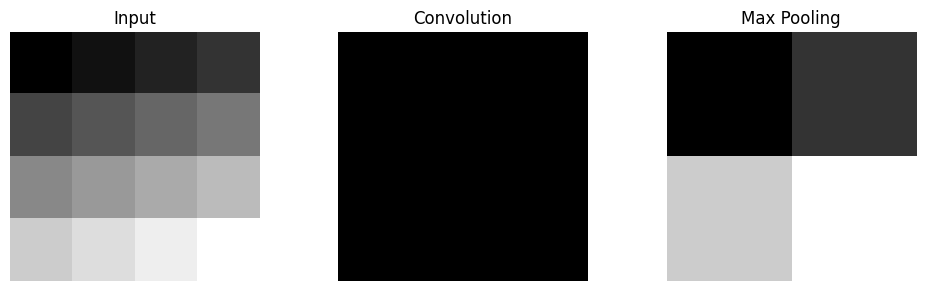

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,3))

plt.subplot(1,3,1)
plt.imshow(image, cmap="gray")
plt.title("Input")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(conv, cmap="gray")
plt.title("Convolution")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(pool_out.numpy()[0,0], cmap="gray")
plt.title("Max Pooling")
plt.axis("off")

plt.tight_layout()
plt.show()


### Result
Thus, filtering, convolution, pooling and their arithmetic were implemented and visualized using PyTorch and TensorFlow.